# Plot Eval Average Return vs Environment Step

This notebook loads one or more training `log.csv` files and plots `Eval_AverageReturn` vs `step`.

In [3]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8")

In [78]:
# Add one or more log.csv paths relative to the hw3 directory.
log_paths = [
    "exp/CartPole-v1_dqn_sd1_20260308_195315/log.csv", # 2.4 File
    "exp/LunarLander-v2_dqn_sd1_20260310_150011/log.csv", # 2.5 Lunar Lander lr = 1e-3
    "exp/MsPacman_dqn_sd1_20260308_200919/log.csv", # 2.5 MsPacMan
    "exp/LunarLander-v2_dqn_sd1_20260310_153421/log.csv", # 2.6 Lunar Lander lr = 1e-2 
    "exp/LunarLander-v2_dqn_sd1_20260310_195325/log.csv", # 2.6 Lunar Lander lr = 1e-4
    "exp/LunarLander-v2_dqn_sd1_20260310_202520/log.csv", #2.6 Lunar Lander lr 5e-3
    "exp/LunarLander-v2_dqn_sd1_20260310_210316/log.csv", #2.6 Lunar Lander lr 5e-4
    
    # Section 3
    "exp/HalfCheetah-v4_sac_sd1_20260309_124409/log.csv", #3.4 Half Cheeta Sac
    "exp/HalfCheetah-v4_sac_autotune_sd1_20260309_224616/log.csv", #3.5 Half Cheeta Sac autotune
    "exp/Hopper-v4_sac_singleq_sd1_20260309_193916/log.csv", #3.6 Hopper-v4_Single
    "exp/Hopper-v4_sac_clipq_sd1_20260309_195205/log.csv", #3.6 Hopper-v4_clipq

]

# Optional custom labels. If empty, folder names are used.
labels = []

In [79]:
def load_eval_curve(csv_path: Path, type=0):
    df = pd.read_csv(csv_path)

    required = ["step", "Eval_AverageReturn"]
    for c in required:
        if c not in df.columns:
            raise ValueError(f"{csv_path} is missing required column: {c}")

    # Keep only rows where eval return is present.
    eval_df = df[["step", "Eval_AverageReturn"]].dropna()
    eval_df = eval_df.sort_values("step")
    test_df = df[["step", "Train_EpisodeReturn"]].dropna()
    test_df = test_df.sort_values("step")

    if type == 1:
        alpha_df = df[["step", "alpha"]].dropna()
        alpha_df = alpha_df.sort_values("step")

        q_df = df[["step", "q_values"]].dropna()
        q_df = q_df.sort_values("step")
    elif type == 2:
        alpha_df = None

        q_df = df[["step", "q_values"]].dropna()
        q_df = q_df.sort_values("step")
    else:
        alpha_df = None
        q_df = None


    print(test_df)
    return eval_df, test_df, alpha_df, q_df


base_dir = Path.cwd()
resolved_paths = [base_dir / p for p in log_paths]

for p in resolved_paths:
    if not p.exists():
        raise FileNotFoundError(f"Missing file: {p}")

print("Loaded paths:")
for p in resolved_paths:
    print(" -", p)

Loaded paths:
 - c:\Users\jiand\unsynced\CS_185\rl_homework_spring2026\hw3\exp\CartPole-v1_dqn_sd1_20260308_195315\log.csv
 - c:\Users\jiand\unsynced\CS_185\rl_homework_spring2026\hw3\exp\LunarLander-v2_dqn_sd1_20260310_150011\log.csv
 - c:\Users\jiand\unsynced\CS_185\rl_homework_spring2026\hw3\exp\MsPacman_dqn_sd1_20260308_200919\log.csv
 - c:\Users\jiand\unsynced\CS_185\rl_homework_spring2026\hw3\exp\LunarLander-v2_dqn_sd1_20260310_153421\log.csv
 - c:\Users\jiand\unsynced\CS_185\rl_homework_spring2026\hw3\exp\LunarLander-v2_dqn_sd1_20260310_195325\log.csv
 - c:\Users\jiand\unsynced\CS_185\rl_homework_spring2026\hw3\exp\LunarLander-v2_dqn_sd1_20260310_202520\log.csv
 - c:\Users\jiand\unsynced\CS_185\rl_homework_spring2026\hw3\exp\LunarLander-v2_dqn_sd1_20260310_210316\log.csv
 - c:\Users\jiand\unsynced\CS_185\rl_homework_spring2026\hw3\exp\HalfCheetah-v4_sac_sd1_20260309_124409\log.csv
 - c:\Users\jiand\unsynced\CS_185\rl_homework_spring2026\hw3\exp\HalfCheetah-v4_sac_autotune_sd1_20

## Section 2

       step  Train_EpisodeReturn
1        16                 17.0
2        56                 40.0
3        71                 15.0
4       109                 38.0
5       140                 31.0
...     ...                  ...
1633  99601                127.0
1634  99693                 92.0
1635  99787                 94.0
1636  99884                 97.0
1637  99973                 89.0

[1518 rows x 2 columns]


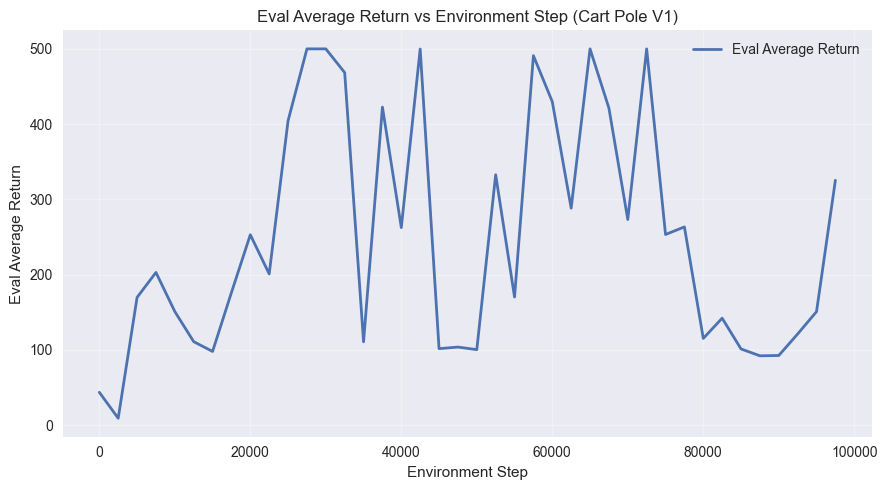

In [80]:
plt.figure(figsize=(9, 5))

path = resolved_paths[0]
eval_df, ___, __, __ = load_eval_curve(path)
plt.plot(eval_df["step"], eval_df["Eval_AverageReturn"], linewidth=2, label="Eval Average Return")

plt.xlabel("Environment Step")
plt.ylabel("Eval Average Return")
plt.title("Eval Average Return vs Environment Step (Cart Pole V1)")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

        step  Train_EpisodeReturn
1         70           -186.23221
2        130           -121.60010
3        231           -186.21680
4        317           -258.60516
5        419           -137.33835
...      ...                  ...
2496  498970            291.92017
2498  499170            272.34122
2499  499381            268.26526
2500  499624            312.02585
2501  499956            279.99872

[2020 rows x 2 columns]


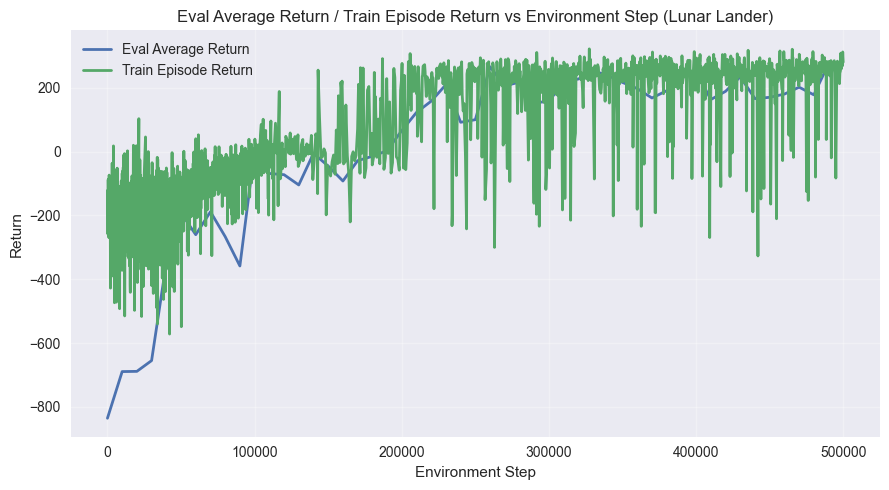

In [81]:
plt.figure(figsize=(9, 5))

path = resolved_paths[1]
eval_df, test_df, __, __ = load_eval_curve(path)
plt.plot(eval_df["step"], eval_df["Eval_AverageReturn"], linewidth=2, label="Eval Average Return")
plt.plot(test_df["step"], test_df["Train_EpisodeReturn"], linewidth=2, label="Train Episode Return")

plt.xlabel("Environment Step")
plt.ylabel("Return")
plt.title("Eval Average Return / Train Episode Return vs Environment Step (Lunar Lander)")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

        step  Train_EpisodeReturn
1        497                300.0
2        969                140.0
3       1449                270.0
4       1970                210.0
5       2417                240.0
...      ...                  ...
2491  996716                840.0
2493  997307                980.0
2495  998209               2040.0
2496  998705                930.0
2498  999475               2600.0

[1517 rows x 2 columns]


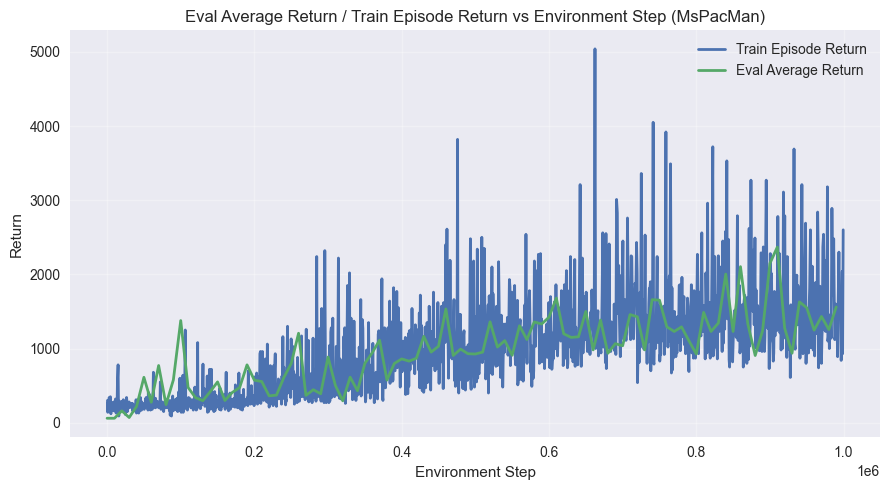

In [82]:
plt.figure(figsize=(9, 5))

path = resolved_paths[2]
eval_df, test_df, __, __ = load_eval_curve(path)
plt.plot(test_df["step"], test_df["Train_EpisodeReturn"], linewidth=2, label="Train Episode Return")
plt.plot(eval_df["step"], eval_df["Eval_AverageReturn"], linewidth=2, label="Eval Average Return")

plt.xlabel("Environment Step")
plt.ylabel("Return")
plt.title("Eval Average Return / Train Episode Return vs Environment Step (MsPacMan)")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

        step  Train_EpisodeReturn
1         70           -186.23221
2        130           -121.60010
3        231           -186.21680
4        317           -258.60516
5        419           -137.33835
...      ...                  ...
2496  498970            291.92017
2498  499170            272.34122
2499  499381            268.26526
2500  499624            312.02585
2501  499956            279.99872

[2020 rows x 2 columns]
        step  Train_EpisodeReturn
1        105          -120.348760
2        214          -223.821720
3        274           -76.538480
4        365            14.464539
5        426           -86.437090
...      ...                  ...
2448  498845           209.079240
2450  499087           258.586240
2451  499486           262.258580
2452  499687           264.954650
2453  499918           280.782400

[1972 rows x 2 columns]
        step  Train_EpisodeReturn
1         68          -112.937750
2        160          -108.592964
3        255          -333.62244

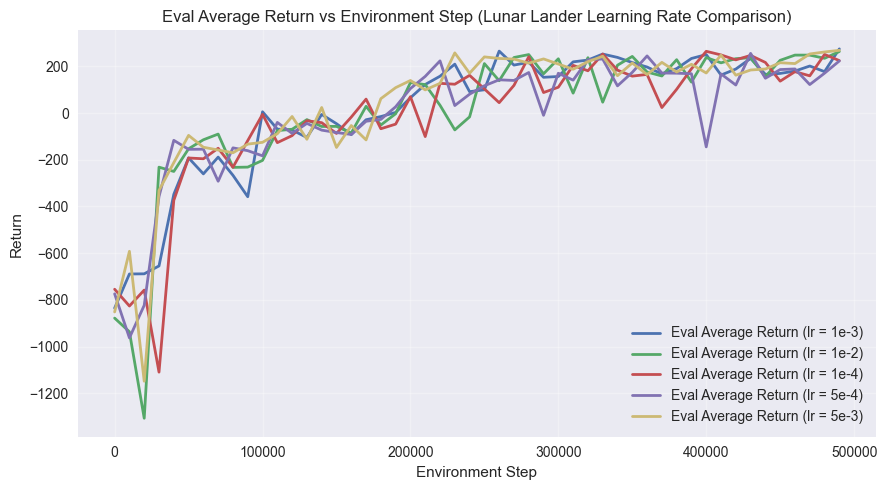

In [83]:
plt.figure(figsize=(9, 5))

lr_1e3 = resolved_paths[1]
lr_1e2 = resolved_paths[3]
lr_1e4 = resolved_paths[4]
lr_5e4 = resolved_paths[5]
lr_5e3 = resolved_paths[6]


eval_df_lr_1e3, test_df, __, __ = load_eval_curve(lr_1e3)
eval_df_lr_1e2, test_df, __, __= load_eval_curve(lr_1e2)
eval_df_lr_1e4, test_df, __, __= load_eval_curve(lr_1e4)
eval_df_lr_5e4, test_df, __, __= load_eval_curve(lr_5e4)
eval_df_lr_5e3, test_df, __, __= load_eval_curve(lr_5e3)

plt.plot(eval_df_lr_1e3["step"], eval_df_lr_1e3["Eval_AverageReturn"], linewidth=2, label="Eval Average Return (lr = 1e-3)")
plt.plot(eval_df_lr_1e2["step"], eval_df_lr_1e2["Eval_AverageReturn"], linewidth=2, label="Eval Average Return (lr = 1e-2)")
plt.plot(eval_df_lr_1e4["step"], eval_df_lr_1e4["Eval_AverageReturn"], linewidth=2, label="Eval Average Return (lr = 1e-4)")
plt.plot(eval_df_lr_5e4["step"], eval_df_lr_5e4["Eval_AverageReturn"], linewidth=2, label="Eval Average Return (lr = 5e-4)")
plt.plot(eval_df_lr_5e3["step"], eval_df_lr_5e3["Eval_AverageReturn"], linewidth=2, label="Eval Average Return (lr = 5e-3)")


plt.xlabel("Environment Step")
plt.ylabel("Return")
plt.title("Eval Average Return vs Environment Step (Lunar Lander Learning Rate Comparison)")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

## Section 3

        step  Train_EpisodeReturn
1        999           -267.89554
2       1999           -291.56490
3       2999           -285.04416
4       3999           -199.34102
5       4999           -198.21431
...      ...                  ...
1983  995999           9617.23300
1985  996999           9734.32900
1987  997999           9812.42000
1989  998999           9670.54700
1991  999999           9792.56600

[1000 rows x 2 columns]


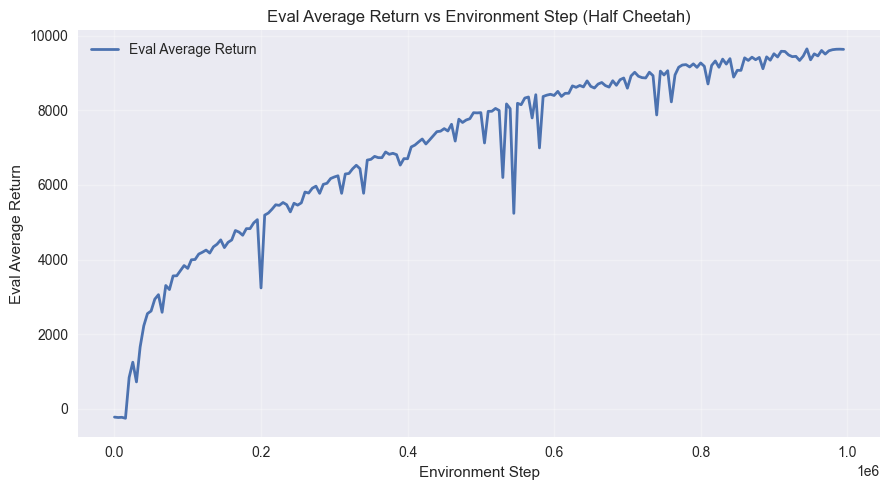

In [69]:
plt.figure(figsize=(9, 5))

path = resolved_paths[7]
eval_df,___ ,___ ,___ = load_eval_curve(path)
plt.plot(eval_df["step"], eval_df["Eval_AverageReturn"], linewidth=2, label="Eval Average Return")

plt.xlabel("Environment Step")
plt.ylabel("Eval Average Return")
plt.title("Eval Average Return vs Environment Step (Half Cheetah)")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

        step  Train_EpisodeReturn
1        999           -229.58210
2       1999           -384.46875
3       2999           -229.48683
4       3999           -168.73242
5       4999           -161.92464
...      ...                  ...
1983  995999           9870.90300
1985  996999           9700.39800
1987  997999           9917.98500
1989  998999           9865.83600
1991  999999           9810.50900

[1000 rows x 2 columns]
        step  Train_EpisodeReturn
1        999           -267.89554
2       1999           -291.56490
3       2999           -285.04416
4       3999           -199.34102
5       4999           -198.21431
...      ...                  ...
1983  995999           9617.23300
1985  996999           9734.32900
1987  997999           9812.42000
1989  998999           9670.54700
1991  999999           9792.56600

[1000 rows x 2 columns]


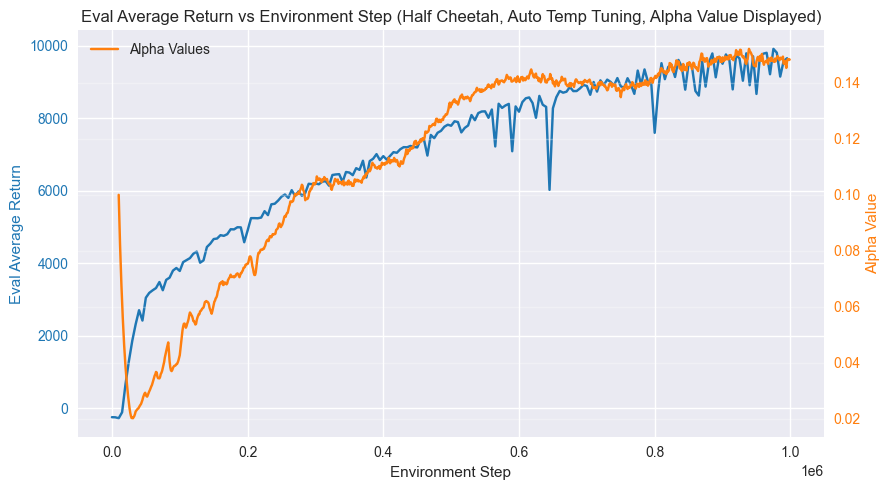

In [84]:
fig, ax1 = plt.subplots(figsize=(9, 5))

path_autoTune = resolved_paths[8]
path_notauto = resolved_paths[7]

eval_df_auto,___ ,alpha_auto ,___ = load_eval_curve(path_autoTune, type=1)
eval_df_not_auto,___ , __ ,___ = load_eval_curve(path_notauto, type=0)

# plt.plot(eval_df_auto["step"], eval_df_auto["Eval_AverageReturn"], linewidth=2, label="Eval Average Return")
# plt.plot(alpha_auto["step"], alpha_auto["alpha"], linewidth=2, label="Eval Average Return")

ax1.plot(eval_df_auto["step"], eval_df_auto["Eval_AverageReturn"], color="tab:blue", label="Eval Average Return")
ax1.set_xlabel("Environment Step")
ax1.set_ylabel("Eval Average Return", color="tab:blue")
ax1.tick_params(axis="y", labelcolor="tab:blue")

ax2 = ax1.twinx()
ax2.plot(alpha_auto["step"], alpha_auto["alpha"], color="tab:orange", label="Alpha Values")
ax2.set_ylabel("Alpha Value", color="tab:orange")
ax2.tick_params(axis="y", labelcolor="tab:orange")

plt.xlabel("Environment Step")
# plt.ylabel("Eval Average Return")
plt.title("Eval Average Return vs Environment Step (Half Cheetah, Auto Temp Tuning, Alpha Value Displayed)")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

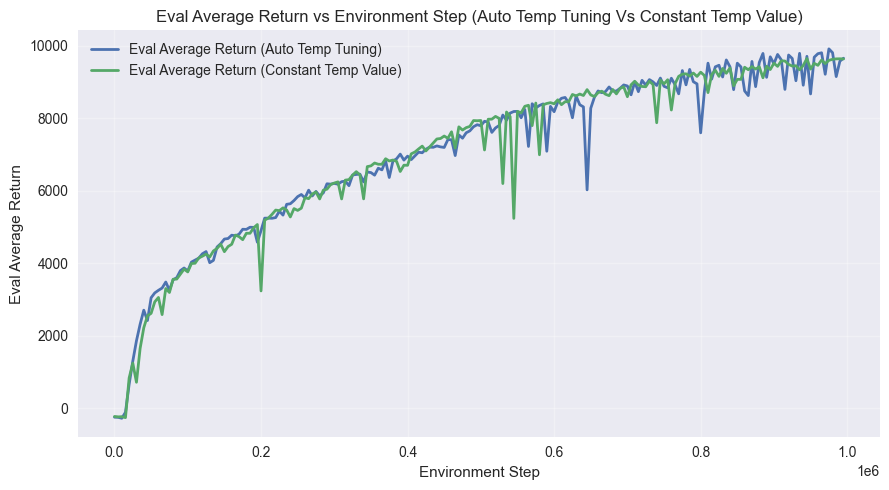

In [71]:
plt.figure(figsize=(9, 5))

plt.plot(eval_df_auto["step"], eval_df_auto["Eval_AverageReturn"], linewidth=2, label="Eval Average Return (Auto Temp Tuning)")
plt.plot(eval_df_not_auto["step"], eval_df_not_auto["Eval_AverageReturn"], linewidth=2, label="Eval Average Return (Constant Temp Value)")

plt.xlabel("Environment Step")
plt.ylabel("Eval Average Return")
plt.title("Eval Average Return vs Environment Step (Auto Temp Tuning Vs Constant Temp Value)")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

        step  Train_EpisodeReturn
1         15             9.739970
2        109           190.025160
3        130            14.794542
4        143            11.596706
5        157            10.582914
...      ...                  ...
3604  499082           745.667360
3605  499375          1048.828900
3606  499565           642.451200
3607  499774           734.257260
3608  499973           616.587300

[3117 rows x 2 columns]
        step  Train_EpisodeReturn
1         65            85.722400
2         89             8.398743
3         97             5.105990
4        128            19.627405
5        140             8.747837
...      ...                  ...
2581  496220          1492.230000
2583  497220          3165.836200
2585  498220          3198.606000
2586  498566          1184.731200
2588  499566          3152.409400

[2097 rows x 2 columns]


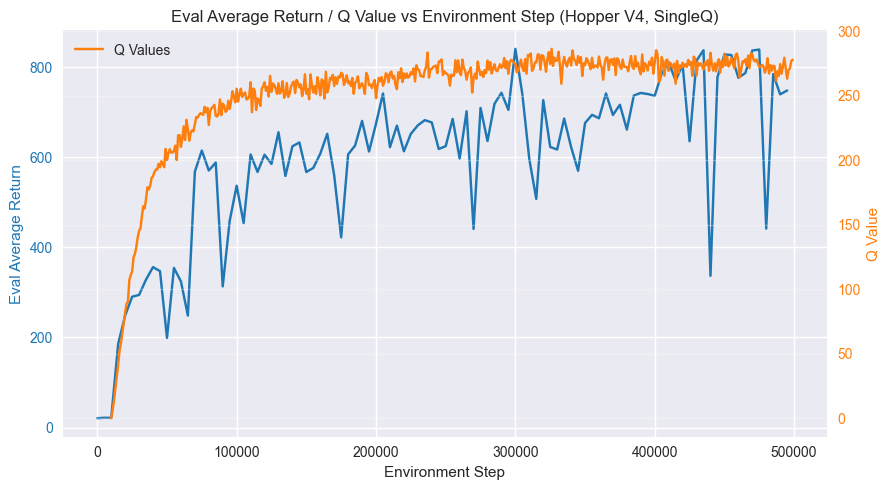

In [85]:
fig, ax1 = plt.subplots(figsize=(9, 5))

path_singleQ = resolved_paths[9]
path_doubleQ = resolved_paths[10]

eval_df_singleQ, ___ ,__ , q_single = load_eval_curve(path_singleQ, type=2)
eval_df_double, ___ , __ , q_double = load_eval_curve(path_doubleQ, type=2)

# plt.plot(eval_df_auto["step"], eval_df_auto["Eval_AverageReturn"], linewidth=2, label="Eval Average Return")
# plt.plot(alpha_auto["step"], alpha_auto["alpha"], linewidth=2, label="Eval Average Return")

ax1.plot(eval_df_singleQ["step"], eval_df_singleQ["Eval_AverageReturn"], color="tab:blue", label="Eval Average Return")
ax1.set_xlabel("Environment Step")
ax1.set_ylabel("Eval Average Return", color="tab:blue")
ax1.tick_params(axis="y", labelcolor="tab:blue")

ax2 = ax1.twinx()
ax2.plot(q_single["step"], q_single["q_values"], color="tab:orange", label="Q Values")
ax2.set_ylabel("Q Value", color="tab:orange")
ax2.tick_params(axis="y", labelcolor="tab:orange")

plt.xlabel("Environment Step")
# plt.ylabel("Eval Average Return")
plt.title("Eval Average Return / Q Value vs Environment Step (Hopper V4, SingleQ)")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

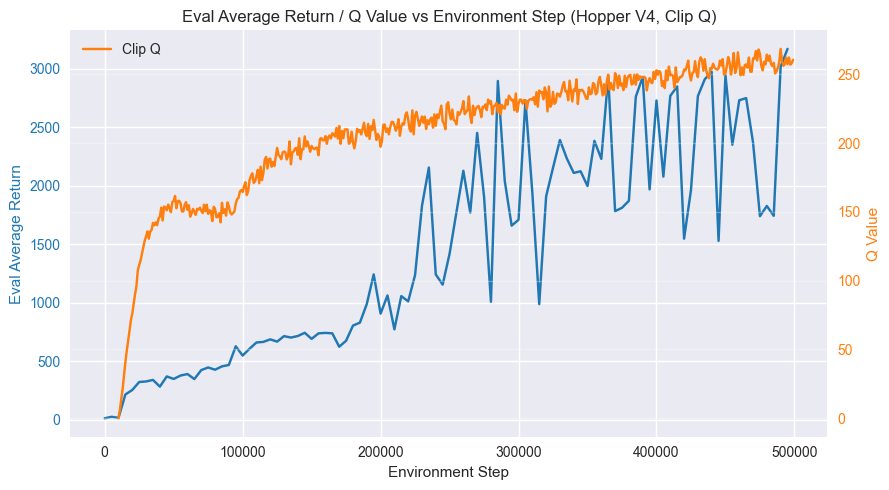

In [ ]:
fig, ax1 = plt.subplots(figsize=(9, 5))

ax1.plot(eval_df_double["step"], eval_df_double["Eval_AverageReturn"], color="tab:blue", label="Eval Average Return")
ax1.set_xlabel("Environment Step")
ax1.set_ylabel("Eval Average Return", color="tab:blue")
ax1.tick_params(axis="y", labelcolor="tab:blue")

ax2 = ax1.twinx()
ax2.plot(q_double["step"], q_double["q_values"], color="tab:orange", label="Q Value")
ax2.set_ylabel("Q Value", color="tab:orange")
ax2.tick_params(axis="y", labelcolor="tab:orange")

plt.xlabel("Environment Step")
# plt.ylabel("Eval Average Return")
plt.title("Eval Average Return / Q Value vs Environment Step (Hopper V4, Clip Q)")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()